In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("sea_clean_data.csv")
df.head()

,Unnamed: 0,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,1.0,0.82,True,5.0,5.0,True,True,47.65444,-122.33629,...,4.83,4.77,4.88,4.57,False,3,3,0,0,0.82
1,1,1.0,0.97,True,10.0,11.0,True,True,47.55017,-122.31937,...,4.92,4.89,4.70,4.69,False,10,0,10,0,1.19
2,3,1.0,0.82,True,5.0,5.0,True,True,47.65405,-122.33744,...,4.78,4.72,4.86,4.74,False,3,3,0,0,0.51
3,4,1.0,1.00,True,1.0,2.0,True,True,47.67947,-122.37196,...,4.98,4.98,4.90,4.90,True,1,1,0,0,6.06
4,5,1.0,0.00,False,1.0,1.0,False,True,47.63941,-122.32897,...,4.46,4.58,4.83,4.36,False,1,1,0,0,0.35


In [4]:
df = df.drop(columns=["Unnamed: 0"])

bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1.0,0.82,1,5.0,5.0,1,1,47.65444,-122.33629,1,...,4.83,4.77,4.88,4.57,0,3,3,0,0,0.82
1,1.0,0.97,1,10.0,11.0,1,1,47.55017,-122.31937,2,...,4.92,4.89,4.70,4.69,0,10,0,10,0,1.19
2,1.0,0.82,1,5.0,5.0,1,1,47.65405,-122.33744,8,...,4.78,4.72,4.86,4.74,0,3,3,0,0,0.51
3,1.0,1.00,1,1.0,2.0,1,1,47.67947,-122.37196,4,...,4.98,4.98,4.90,4.90,1,1,1,0,0,6.06
4,1.0,0.00,0,1.0,1.0,0,1,47.63941,-122.32897,3,...,4.46,4.58,4.83,4.36,0,1,1,0,0,0.35


In [5]:
y = df["review_scores_rating"]
X = df.drop(columns=["review_scores_rating"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#  Train Gradient Boosting Model

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [7]:
y_pred = model.predict(X_test)

In [8]:
#  Evaluate model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.05012952301706127
RMSE: 0.10076492189473987
R2 Score: 0.8903891131222643


In [9]:
#  Feature importance

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(importance_df.head(10))


Top Important Features:
                                         Feature  Importance
33                           review_scores_value    0.546032
28                        review_scores_accuracy    0.250531
29                     review_scores_cleanliness    0.117355
31                   review_scores_communication    0.041526
19                               availability_90    0.005907
13                                         price    0.005790
24                              availability_eoy    0.004373
37  calculated_host_listings_count_private_rooms    0.003651
32                        review_scores_location    0.003063
30                         review_scores_checkin    0.002480


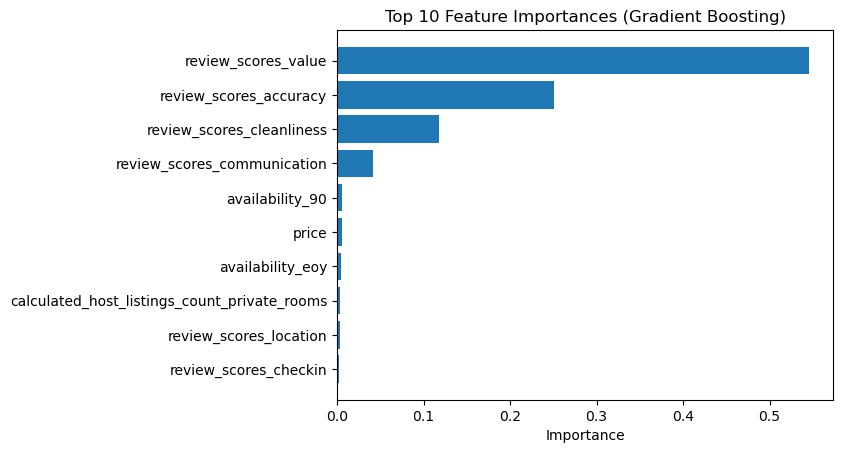

In [10]:
#  Plot feature importance

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.show()

In [11]:
df.describe()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,...,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000
mean,0.983098,0.936789,0.636419,31.071531,59.151236,0.987124,0.894952,47.626648,-122.334880,4.223993,...,4.885005,4.890746,4.839918,4.728786,0.301655,12.006949,9.680973,2.263029,0.034539,2.428845
std,0.090124,0.143524,0.481079,147.257068,361.093291,0.112749,0.306647,0.050140,0.034357,2.645693,...,0.229473,0.256207,0.243495,0.332246,0.459023,25.584907,23.001666,9.583673,0.498395,2.159558
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,47.498030,-122.419040,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,1.000000,0.950000,0.000000,1.000000,1.000000,1.000000,1.000000,47.599750,-122.358544,2.000000,...,4.870000,4.890000,4.800000,4.670000,0.000000,1.000000,1.000000,0.000000,0.000000,0.850000
50%,1.000000,0.990000,1.000000,3.000000,4.000000,1.000000,1.000000,47.626533,-122.333008,4.000000,...,4.950000,4.970000,4.900000,4.810000,0.000000,2.000000,2.000000,0.000000,0.000000,2.110000
75%,1.000000,1.000000,1.000000,13.000000,19.000000,1.000000,1.000000,47.664820,-122.310341,6.000000,...,5.000000,5.000000,4.970000,4.900000,1.000000,9.000000,6.000000,0.000000,0.000000,3.490000
max,1.000000,1.000000,1.000000,2989.000000,8403.000000,1.000000,1.000000,47.734010,-122.240870,16.000000,...,5.000000,5.000000,5.000000,5.000000,1.000000,138.000000,130.000000,75.000000,8.000000,60.330000


In [12]:
df['price'].max()

50039.0